### This file has Data Analytics in the inital part for EDA as well as for understanding the dataset, after which there is implementation of Machine Learning Techniques on this specific dataset (fetched using Binance API).

### Importing Libraries

In [3]:
import pandas as pd
import numpy as np

### Data Loading

In [4]:
df=pd.read_csv('bitcoin_data.csv')

In [5]:
df.head()

,timestamp,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume,ignore
0,2023-01-01 00:00:00,16541.77,16545.70,16508.39,16529.67,4364.83570,1.672535e+12,7.214629e+07,149854.0,2179.94772,3.603235e+07,0.0
1,2023-01-01 01:00:00,16529.59,16556.80,16525.78,16551.47,3590.06669,1.672538e+12,5.937676e+07,126556.0,1730.24901,2.861742e+07,0.0
2,2023-01-01 02:00:00,16551.47,16559.77,16538.14,16548.19,3318.84038,1.672542e+12,5.491945e+07,115398.0,1611.12302,2.666087e+07,0.0
3,2023-01-01 03:00:00,16548.19,16548.19,16518.21,16533.04,4242.08050,1.672546e+12,7.012254e+07,137724.0,2096.09287,3.464904e+07,0.0
4,2023-01-01 04:00:00,16533.04,16535.97,16511.92,16521.85,4285.00909,1.672549e+12,7.080264e+07,129535.0,2188.40175,3.615982e+07,0.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19704 entries, 0 to 19703
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   timestamp                     19704 non-null  object 
 1   open                          19704 non-null  float64
 2   high                          19704 non-null  float64
 3   low                           19704 non-null  float64
 4   close                         19704 non-null  float64
 5   volume                        19704 non-null  float64
 6   close_time                    19704 non-null  float64
 7   quote_asset_volume            19704 non-null  float64
 8   number_of_trades              19704 non-null  float64
 9   taker_buy_base_asset_volume   19704 non-null  float64
 10  taker_buy_quote_asset_volume  19704 non-null  float64
 11  ignore                        19704 non-null  float64
dtypes: float64(11), object(1)
memory usage: 1.8+ MB


In [7]:
df.columns

Index(['timestamp', 'open', 'high', 'low', 'close', 'volume', 'close_time',
       'quote_asset_volume', 'number_of_trades', 'taker_buy_base_asset_volume',
       'taker_buy_quote_asset_volume', 'ignore'],
      dtype='object')

### Data Pre-Processing

In [8]:
df.isnull().sum()

timestamp                       0
open                            0
high                            0
low                             0
close                           0
volume                          0
close_time                      0
quote_asset_volume              0
number_of_trades                0
taker_buy_base_asset_volume     0
taker_buy_quote_asset_volume    0
ignore                          0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df['ignore']

0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
19699    0.0
19700    0.0
19701    0.0
19702    0.0
19703    0.0
Name: ignore, Length: 19704, dtype: float64

In [11]:
df['ignore'].unique()

array([0.])

In [12]:
df.drop(columns=['ignore'], inplace=True)

In [13]:
df.dtypes

timestamp                        object
open                            float64
high                            float64
low                             float64
close                           float64
volume                          float64
close_time                      float64
quote_asset_volume              float64
number_of_trades                float64
taker_buy_base_asset_volume     float64
taker_buy_quote_asset_volume    float64
dtype: object

In [14]:
df['number_of_trades'] = df['number_of_trades'].astype('int64')

In [15]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [16]:
df['close_time'] = pd.to_datetime(df['close_time'], unit='ms')

In [17]:
df['time_diff'] = df['timestamp'].diff().dt.total_seconds()
print(df['time_diff'].value_counts())

time_diff
3600.0    19702
7200.0        1
Name: count, dtype: int64


### Exploratory Data Analysis

In [18]:
df[['open', 'high', 'low', 'close', 'volume', 'number_of_trades']].describe()

,open,high,low,close,volume,number_of_trades
count,19704.000000,19704.000000,19704.00000,19704.000000,19704.000000,1.970400e+04
mean,52427.663443,52615.273071,52234.27714,52431.020571,2641.984079,1.194149e+05
std,25120.993379,25227.981685,25011.03269,25120.614954,4701.077871,1.396621e+05
min,16513.330000,16534.030000,16499.01000,16513.340000,0.000000,0.000000e+00
25%,28288.145000,28383.215000,28182.17000,28289.292500,671.743370,3.517125e+04
50%,51055.535000,51171.030000,50866.30000,51058.100000,1146.756255,6.496350e+04
75%,67765.925000,67999.230000,67569.66250,67767.640000,2310.810092,1.448968e+05
max,108320.000000,109588.000000,107780.51000,108320.010000,80041.752040,1.542742e+06


### Importing Visualization Libraries

In [19]:
from matplotlib import pyplot as plt
from matplotlib import rcParams
import matplotlib.dates as mdates

In [20]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


### Bitcoin Closing Price over the Time

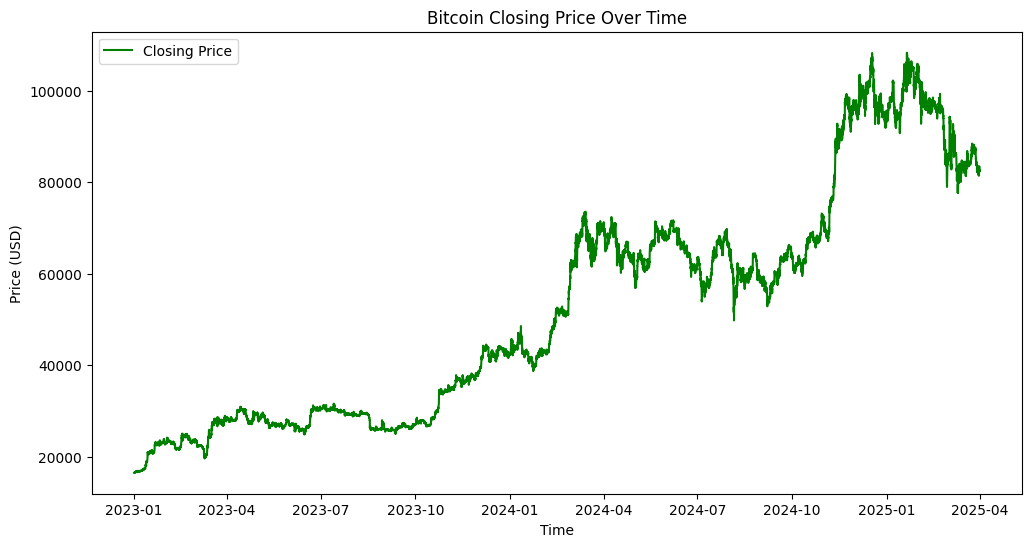

In [21]:
plt.figure(figsize=(12, 6), facecolor='white')
plt.plot(df['timestamp'], df['close'], label='Closing Price', color='green')
plt.xlabel('Time', color='black')
plt.ylabel('Price (USD)', color='black')
plt.title('Bitcoin Closing Price Over Time', color='black')
rcParams['text.color'] = 'black'
rcParams['axes.labelcolor'] = 'black'
rcParams['xtick.color'] = 'black'
rcParams['ytick.color'] = 'black'
rcParams['axes.titlecolor'] = 'black'
plt.legend()
plt.show()

### Importing Plotly for Interactive Visualization

In [22]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

### Bitcoin Trading Volume

In [ ]:
# creating a base figure
fig = go.Figure()

# hover 
fig.add_trace(go.Scatter(
    x=df['timestamp'],
    y=df['volume'],
    mode='lines',
    name='Trading Volume',
    line=dict(color='#FF6B00', width=2.5),
    hovertemplate='<b>%{x|%d %b %Y}</b><br>Volume: %{y:.2f} BTC<extra></extra>',
    fill='tozeroy',
    fillcolor='rgba(255, 107, 0, 0.1)'
))

# Finding and highlight peak/highest volume
max_volume = df['volume'].max()
max_date = df.loc[df['volume'].idxmax(), 'timestamp']
fig.add_trace(go.Scatter(
    x=[max_date],
    y=[max_volume],
    mode='markers+text',
    marker=dict(color='#C70039', size=10, line=dict(width=2, color='White')),
    name='Peak Volume',
    text=[f'Max: {max_volume:,.2f} BTC'],
    textposition='middle right'
))

# Layout customization
fig.update_layout(
    title=dict(
        text='<b>Bitcoin Trading Volume Analysis</b>',
        font=dict(size=24, family='Arial', color='#2A2A2A'),
        x=0.03,
        y=0.93
    ),
    xaxis=dict(
        title=None,
        gridcolor='#F0F0F0',
        showline=True,
        linecolor='#B0B0B0',
        rangeslider=dict(visible=True),
        tickformat='%b %Y'
    ),
    yaxis=dict(
        title='Volume (BTC)',
        gridcolor='#F0F0F0',
        showline=True,
        linecolor='#B0B0B0',
        tickprefix='₿itcoin ',
        title_standoff=20
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    hovermode='x unified',
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='right',
        x=1,
        bgcolor='rgba(255,255,255,0.9)'
    ),
    margin=dict(l=20, r=20, t=100, b=20),
    font=dict(family='Arial', color='#404040'),
    height=600,
    width=1200
)

# annotations
fig.add_annotation(
    xref='paper', yref='paper',
    x=0.05, y=-0.15,
    text='Data Source: Bitcoin Historical Data | Visualization by Your Name',
    showarrow=False,
    font=dict(size=12, color='#808080')
)

# Adding responsive features
fig.update_xaxes(
    rangeselector=dict(
        buttons=list([
            dict(count=1, label="1m", step="month", stepmode="backward"),
            dict(count=6, label="6m", step="month", stepmode="backward"),
            dict(count=1, label="YTD", step="year", stepmode="todate"),
            dict(count=1, label="1y", step="year", stepmode="backward"),
            dict(step="all")
        ]),
        bgcolor='#F8F8F8',
        activecolor='#E0E0E0',
        font=dict(color='#404040')
    )
)

from IPython.display import HTML
HTML(fig.to_html())

### Volatility of Bitcoin Price

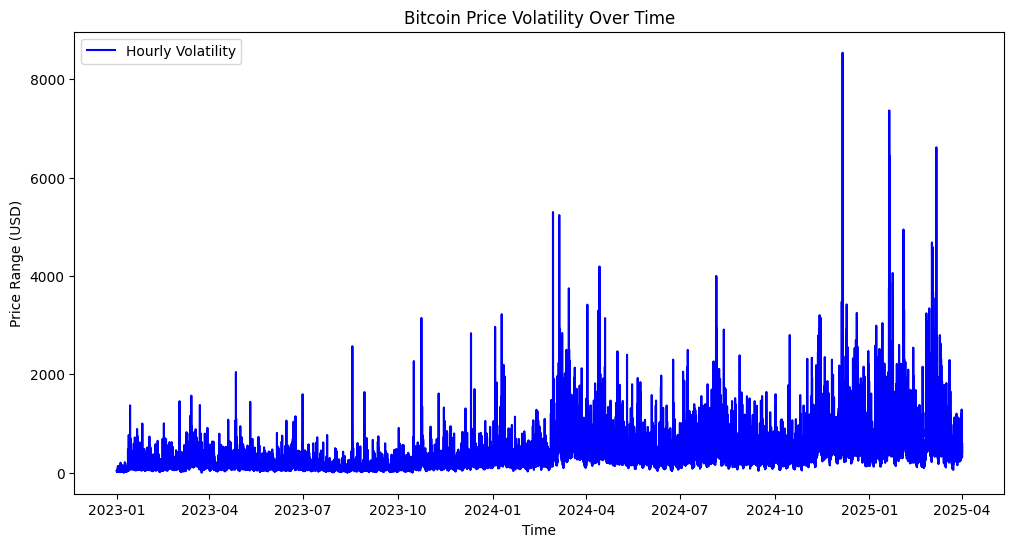

In [24]:
df['volatility'] = df['high'] - df['low']
plt.figure(figsize=(12, 6))
plt.plot(df['timestamp'], df['volatility'], label='Hourly Volatility', color='blue')
plt.xlabel('Time')
plt.ylabel('Price Range (USD)')
plt.title('Bitcoin Price Volatility Over Time')
plt.legend()
plt.show()

In [25]:
# Boxplot for Closing Price Distribution
fig = px.box(df, y='close', title='Bitcoin Closing Price Distribution', 
             labels={'close': 'Closing Price (USD)'})
fig.update_layout(title_font_color='black', 
                  paper_bgcolor='white', 
                  plot_bgcolor='white',
                  font=dict(color='black'))
fig.show()

# hover over the boxplot for more details

### EDA using Technical Analysis Library

In [2]:
import talib
# might need to install TA-Lib, if not already installed.

### Volatility Analysis

In [27]:
# Bollinger Bands

upper_band, middle_band, lower_band = talib.BBANDS(df['close'], timeperiod=20, nbdevup=2, nbdevdn=2, matype=0)
df['upper_band'] = upper_band
df['middle_band'] = middle_band
df['lower_band'] = lower_band

print(upper_band)
print("\n")
print(middle_band)
print("\n")
print(lower_band)

0                 NaN
1                 NaN
2                 NaN
3                 NaN
4                 NaN
             ...     
19699    83571.451808
19700    83588.535195
19701    83592.051511
19702    83567.836617
19703    83570.131000
Length: 19704, dtype: float64


0               NaN
1               NaN
2               NaN
3               NaN
4               NaN
            ...    
19699    82374.4000
19700    82404.9480
19701    82429.3325
19702    82480.3330
19703    82520.5875
Length: 19704, dtype: float64


0                 NaN
1                 NaN
2                 NaN
3                 NaN
4                 NaN
             ...     
19699    81177.348192
19700    81221.360805
19701    81266.613489
19702    81392.829383
19703    81471.044000
Length: 19704, dtype: float64


In [28]:
# Average True Range (ATR)

df['ATR_14'] = talib.ATR(df['high'], df['low'], df['close'], timeperiod=14)
print(df['ATR_14'])

0               NaN
1               NaN
2               NaN
3               NaN
4               NaN
            ...    
19699    703.224757
19700    676.578703
19701    650.171653
19702    646.795106
19703    629.498313
Name: ATR_14, Length: 19704, dtype: float64


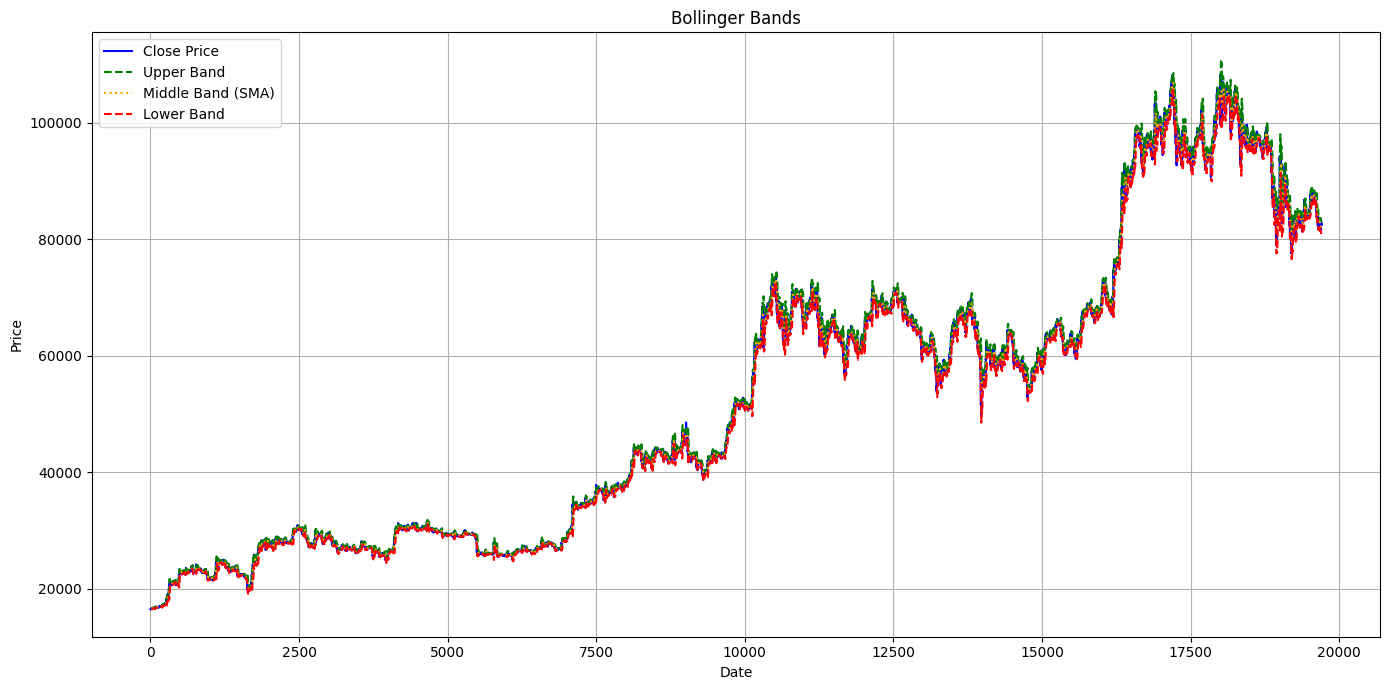

In [29]:
# Plotting the Closing Price and Bollinger Bands
plt.figure(figsize=(14, 7))

# Plotting close price
plt.plot(df['close'], label='Close Price', color='blue')

# Plotting Bollinger Bands
plt.plot(df['upper_band'], label='Upper Band', color='green', linestyle='--')
plt.plot(df['middle_band'], label='Middle Band (SMA)', color='orange', linestyle=':')
plt.plot(df['lower_band'], label='Lower Band', color='red', linestyle='--')

plt.fill_between(df.index, df['lower_band'], df['upper_band'], color='lightgray', alpha=0.3)

# Adding labels and legend
plt.title('Bollinger Bands')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()

plt.show()


### Pattern Recognition

In [30]:
df['CDLDOJI'] = talib.CDLDOJI(df['open'], df['high'], df['low'], df['close'])
df['CDLHAMMER'] = talib.CDLHAMMER(df['open'], df['high'], df['low'], df['close'])

In [31]:
import pandas as pd

df = pd.read_csv('bitcoin_data.csv')

df['timestamp'] = pd.to_datetime(df['timestamp'])
df.sort_values('timestamp', inplace=True)

# TA-Lib pattern recognition
df['CDLDOJI'] = talib.CDLDOJI(df['open'], df['high'], df['low'], df['close'])
df['CDLHAMMER'] = talib.CDLHAMMER(df['open'], df['high'], df['low'], df['close'])

# Filtering pattern signals
doji_signals = df[df['CDLDOJI'] != 0]
hammer_signals = df[df['CDLHAMMER'] != 0]

# Plotting candlestick chart
fig = go.Figure(data=[
    go.Candlestick(
        x=df['timestamp'],
        open=df['open'],
        high=df['high'],
        low=df['low'],
        close=df['close'],
        name='Price'
    ),
    go.Scatter(
        x=doji_signals['timestamp'],
        y=doji_signals['close'],
        mode='markers',
        marker=dict(color='orange', size=10, symbol='cross'),
        name='Doji'
    ),
    go.Scatter(
        x=hammer_signals['timestamp'],
        y=hammer_signals['close'],
        mode='markers',
        marker=dict(color='green', size=10, symbol='triangle-up'),
        name='Hammer'
    )
])

fig.update_layout(
    title='Candlestick Chart with Doji & Hammer Patterns',
    xaxis_title='Date',
    yaxis_title='Price',
    xaxis_rangeslider_visible=False
)

fig.show()


### Price and SMA, RSI, MACD

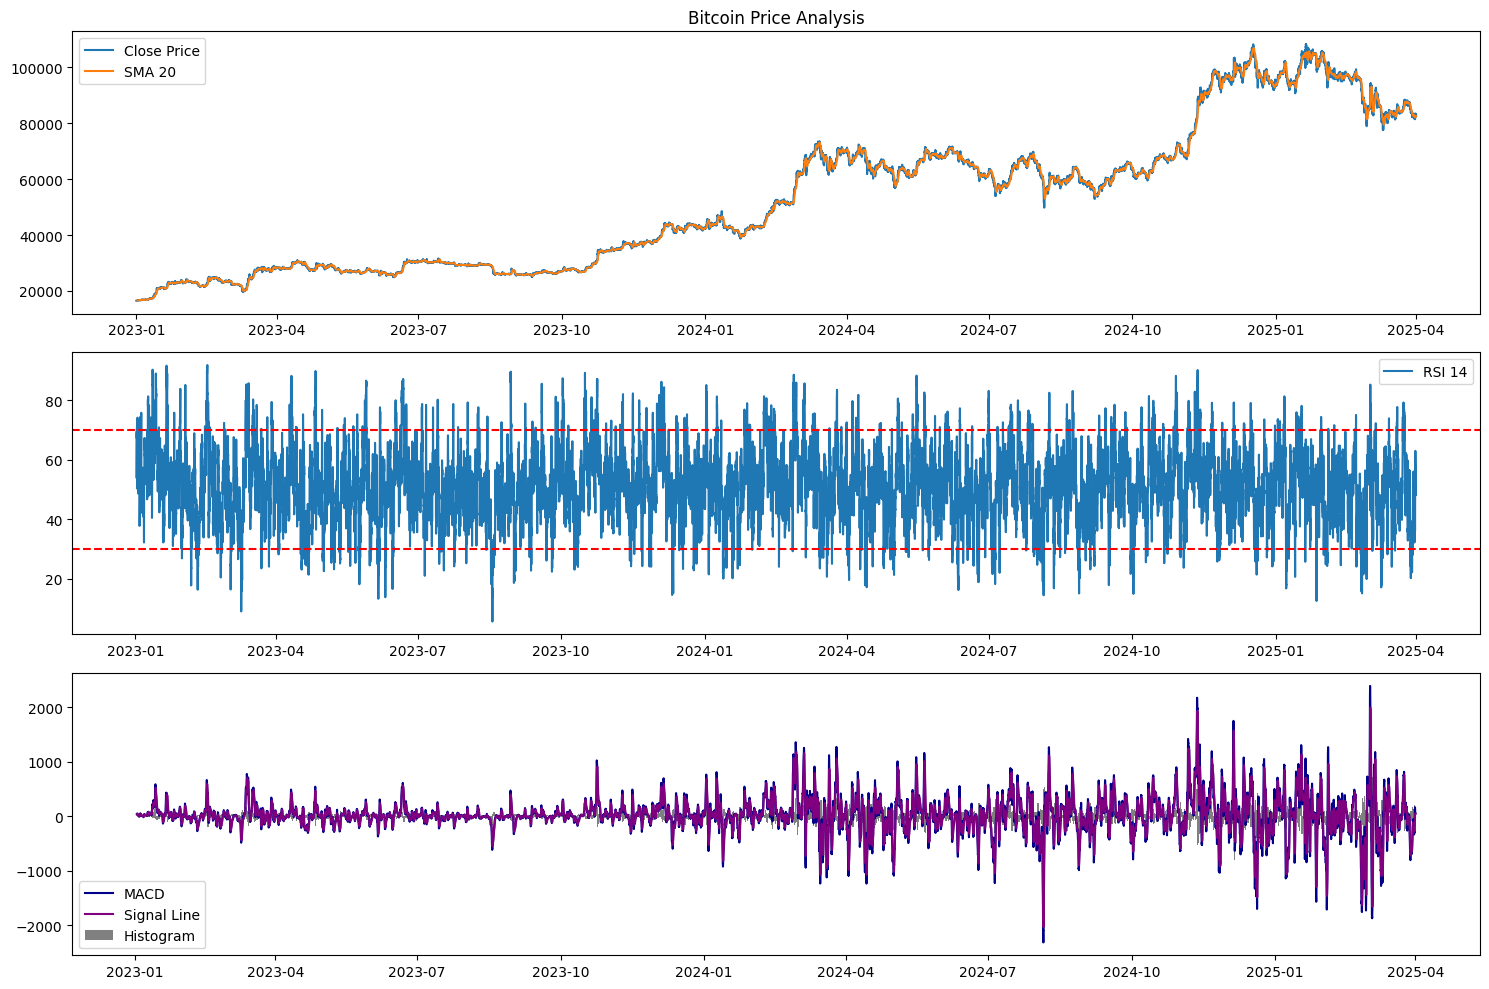

In [32]:
df = pd.read_csv('bitcoin_data.csv', parse_dates=['timestamp'])
df.set_index('timestamp', inplace=True)

df['SMA_20'] = talib.SMA(df['close'], 20)
df['RSI_14'] = talib.RSI(df['close'], 14)
df['MACD'], df['MACD_Signal'], df['MACD_Hist'] = talib.MACD(df['close'], 12, 26, 9)
df['BB_Upper'], df['BB_Middle'], df['BB_Lower'] = talib.BBANDS(df['close'], 20, 2, 2)

plt.figure(figsize=(15, 10))

# Price and SMA
plt.subplot(3, 1, 1)
plt.plot(df['close'], label='Close Price')
plt.plot(df['SMA_20'], label='SMA 20')
plt.title('Bitcoin Price Analysis')
plt.legend()

# RSI
plt.subplot(3, 1, 2)
plt.plot(df['RSI_14'], label='RSI 14')
plt.axhline(30, linestyle='--', color='red')
plt.axhline(70, linestyle='--', color='red')
plt.legend()

# MACD
plt.subplot(3, 1, 3)
plt.plot(df['MACD'], label='MACD', color='darkblue')
plt.plot(df['MACD_Signal'], label='Signal Line',color='purple')
plt.bar(df.index, df['MACD_Hist'], label='Histogram', color='gray')
plt.legend()

plt.tight_layout()
plt.show()

#### <b>To compare the performance of Linear Regression and Decision Tree Regressor in predicting Bitcoin’s hourly closing prices, assess their effectiveness using regression metrics, and visualize their predictions and errors to understand model behavior.</b>

# Linear Regression

### Importing Libraries

In [33]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error,root_mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

### Loading Data and pre-processing

In [34]:
main_df=pd.read_csv('bitcoin_data.csv', parse_dates=['timestamp'], index_col='timestamp')

In [35]:
main_df.isnull().sum()

open                            0
high                            0
low                             0
close                           0
volume                          0
close_time                      0
quote_asset_volume              0
number_of_trades                0
taker_buy_base_asset_volume     0
taker_buy_quote_asset_volume    0
ignore                          0
dtype: int64

In [36]:
target='close'

In [37]:
# previous hour's close price
main_df['prev_close'] = main_df['close'].shift(1)

In [38]:
# dropping Na values
main_df=main_df.dropna()

### Defining features and target

In [39]:
features=['prev_close']
X = main_df[features]
y = main_df[target]

### Splitting data into training and testing set

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, shuffle=False)

In [41]:
# feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### Training the Model

In [42]:
linear_reg_model = LinearRegression()
linear_reg_model.fit(X_train_scaled, y_train)
y_pred_lr = linear_reg_model.predict(X_test_scaled)

### Evaluating the Linear Regression Model

In [43]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr=np.sqrt(mse_lr)

In [44]:
print(f"Linear Regression - MAE: {mae_lr}, MSE: {mse_lr}, R2: {r2_lr}, RMSE: {rmse_lr}")

Linear Regression - MAE: 349.66426240733193, MSE: 284929.4719503664, R2: 0.9974214410048813, RMSE: 533.7878529438136


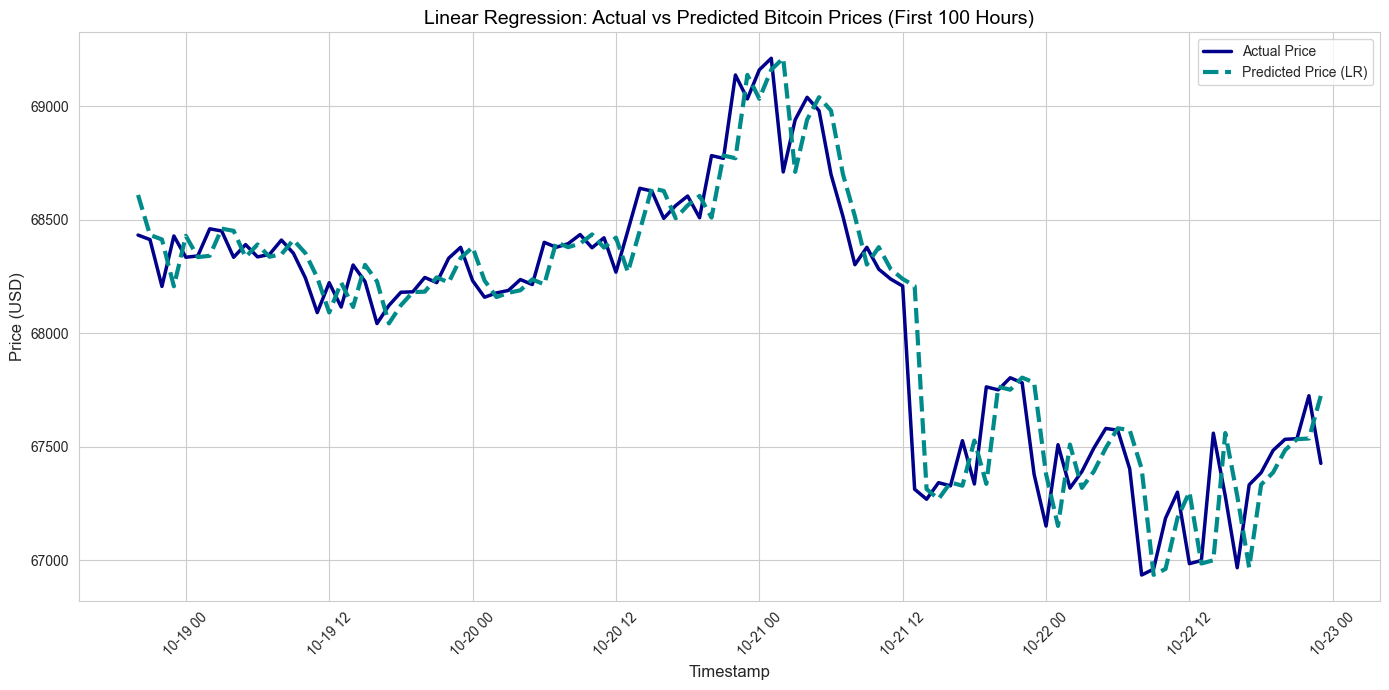

In [45]:
sns.set_style("whitegrid")

plt.figure(figsize=(14, 7))
plt.plot(y_test.index[:100], y_test[:100], label='Actual Price', color='darkblue', linewidth=2.5)
plt.plot(y_test.index[:100], y_pred_lr[:100], label='Predicted Price (LR)', color='darkcyan', linestyle='--', linewidth=3)
plt.title('Linear Regression: Actual vs Predicted Bitcoin Prices (First 100 Hours)', fontsize=14)
plt.xlabel('Timestamp', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Residual Plot with Histogram for Linear Regression

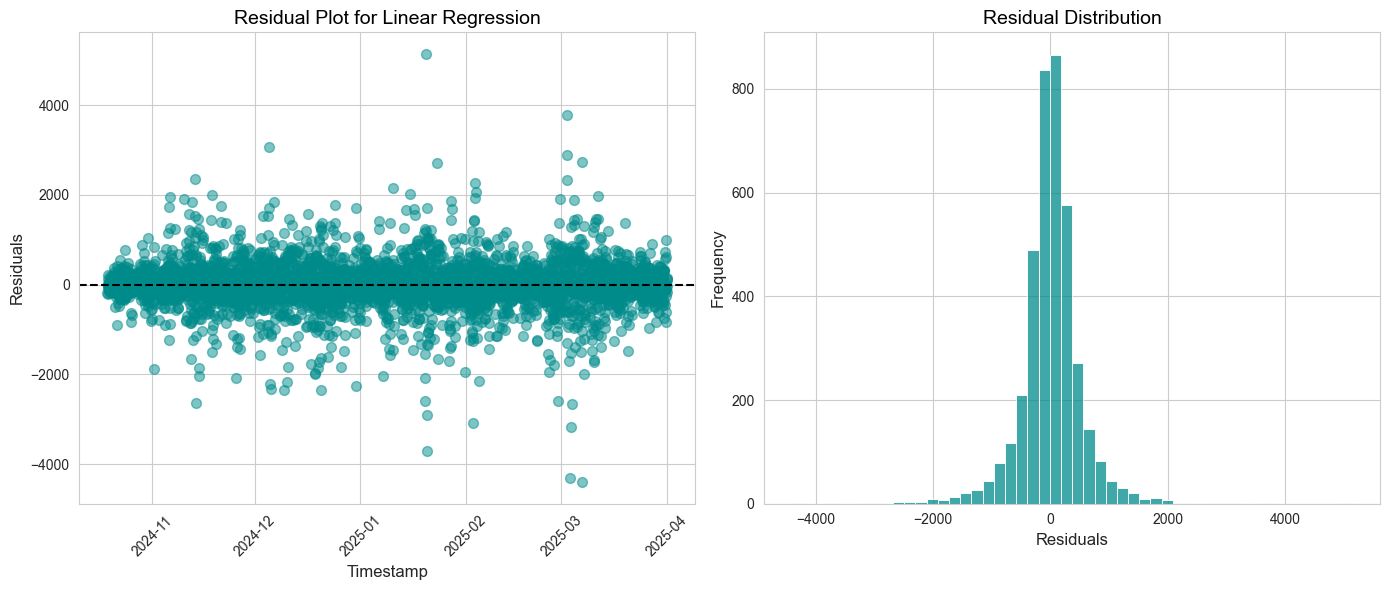

In [46]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
residuals_lr = y_test - y_pred_lr
# Scatter plot
ax1.scatter(y_test.index, residuals_lr, color='darkcyan', alpha=0.5, s=50)
ax1.axhline(y=0, color='black', linestyle='--')
ax1.set_title('Residual Plot for Linear Regression', fontsize=14)
ax1.set_xlabel('Timestamp', fontsize=12)
ax1.set_ylabel('Residuals', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
# Histogram
sns.histplot(residuals_lr, bins=50, color='darkcyan', ax=ax2)
ax2.set_title('Residual Distribution', fontsize=14)
ax2.set_xlabel('Residuals', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

### Prediction Error Over the Time for Linear Regression

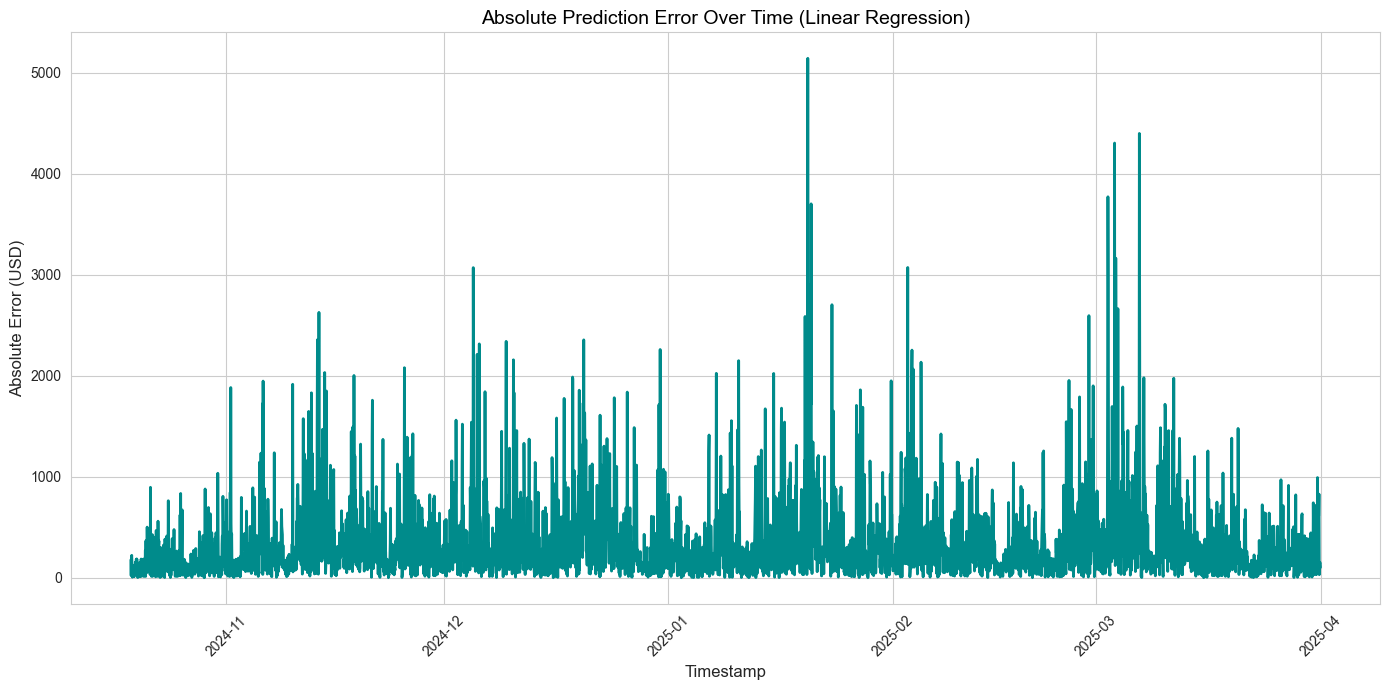

In [47]:
abs_errors_lr = np.abs(y_test - y_pred_lr)
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, abs_errors_lr, color='darkcyan', linewidth=2)
plt.title('Absolute Prediction Error Over Time (Linear Regression)', fontsize=14)
plt.xlabel('Timestamp', fontsize=12)
plt.ylabel('Absolute Error (USD)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Feature Importance for Linear Regression

In [48]:
print("\nFeature Importance for Linear Regression:")
print(f"  {features[0]}: {linear_reg_model.coef_[0]}")


Feature Importance for Linear Regression:
  prev_close: 17160.666302320464


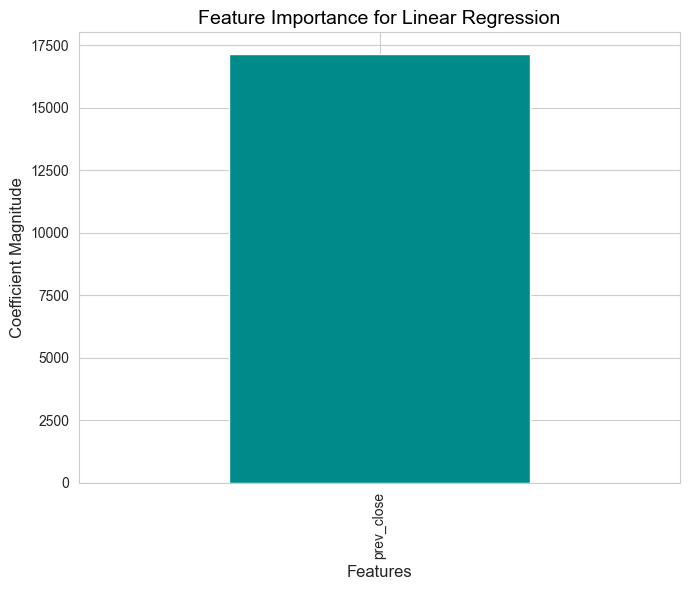

In [49]:
plt.figure(figsize=(7, 6))
feature_importance_lr = pd.Series(np.abs(linear_reg_model.coef_), index=features) 
feature_importance_lr.plot(kind='bar', color='darkcyan')
plt.title('Feature Importance for Linear Regression', fontsize=14)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Coefficient Magnitude', fontsize=12)
plt.tight_layout()
plt.show()

# Decision Tree Regressor

### Training and Testing the model

In [50]:
decision_tree_model = DecisionTreeRegressor(random_state=42)
decision_tree_model.fit(X_train_scaled, y_train)
y_pred_dt = decision_tree_model.predict(X_test_scaled)

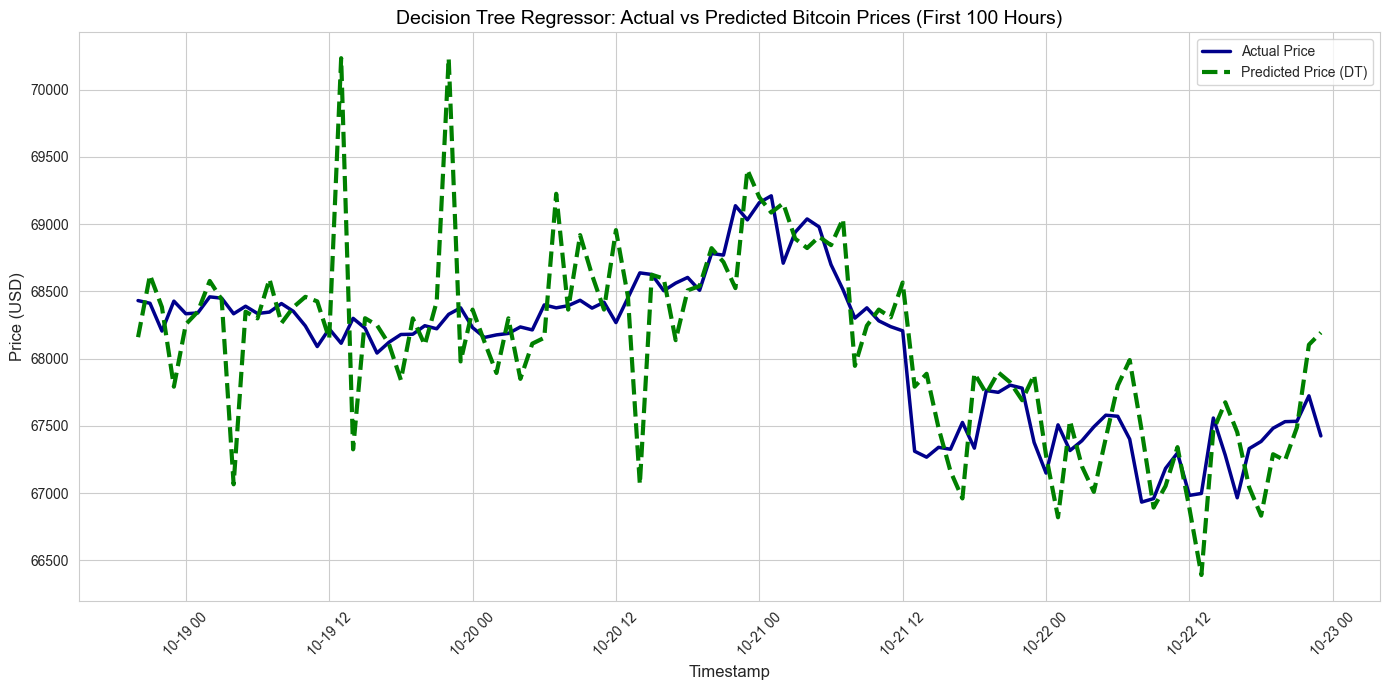

In [51]:
sns.set_style("whitegrid")

plt.figure(figsize=(14, 7))
plt.plot(y_test.index[:100], y_test[:100], label='Actual Price', color='darkblue', linewidth=2.5)
plt.plot(y_test.index[:100], y_pred_dt[:100], label='Predicted Price (DT)', color='green', linestyle='--', linewidth=3)
plt.title('Decision Tree Regressor: Actual vs Predicted Bitcoin Prices (First 100 Hours)', fontsize=14)
plt.xlabel('Timestamp', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [52]:
# Metrics for Decision Tree Regressor

mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
print(f"Decision Tree Regressor - MAE: {mae_dt}, MSE: {mse_dt}, R2: {r2_dt}, RMSE: {rmse_dt}")

Decision Tree Regressor - MAE: 18377.9405163664, MSE: 426481901.9529467, R2: -2.8595822924476355, RMSE: 20651.438253858898


### Residual Plot with Histogram for Decision Tree Regressor

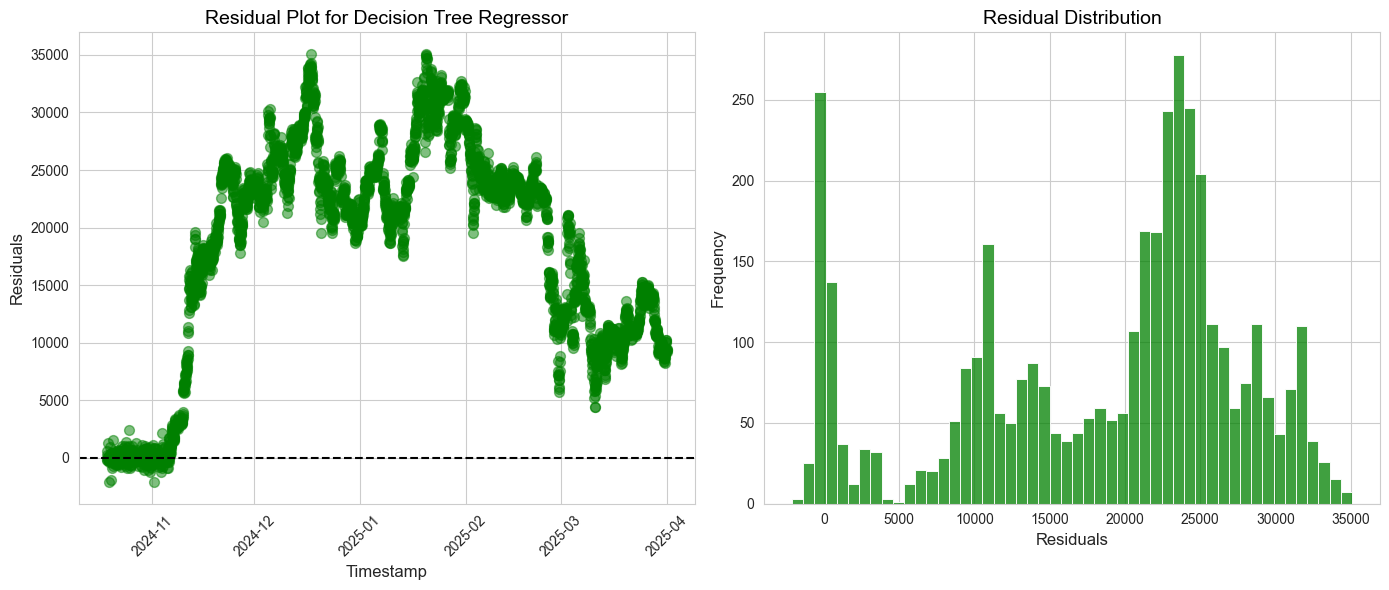

In [54]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
residuals_dt = y_test - y_pred_dt
# Scatter plot
ax1.scatter(y_test.index, residuals_dt, color='green', alpha=0.5, s=50)
ax1.axhline(y=0, color='black', linestyle='--')
ax1.set_title('Residual Plot for Decision Tree Regressor', fontsize=14)
ax1.set_xlabel('Timestamp', fontsize=12)
ax1.set_ylabel('Residuals', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
# Histogram
sns.histplot(residuals_dt, bins=50, color='green', ax=ax2)
ax2.set_title('Residual Distribution', fontsize=14)
ax2.set_xlabel('Residuals', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

### Prediction Error Over the Time for Decision Tree Regressor

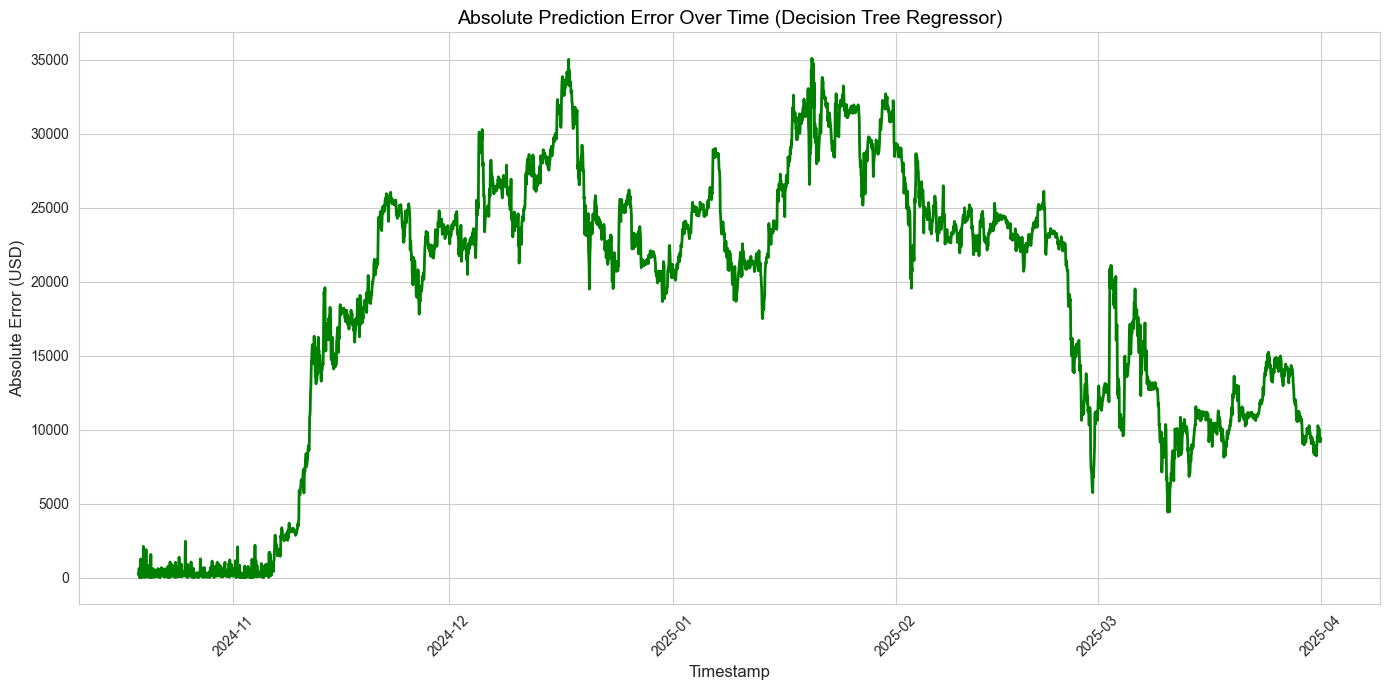

In [55]:
abs_errors_dt = np.abs(y_test - y_pred_dt)
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, abs_errors_dt, color='green', linewidth=2)
plt.title('Absolute Prediction Error Over Time (Decision Tree Regressor)', fontsize=14)
plt.xlabel('Timestamp', fontsize=12)
plt.ylabel('Absolute Error (USD)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Feature Importance for Decision Tree Regressor

In [56]:
print("\nFeature Importance for Decision Tree Regressor:")
for i, feature in enumerate(features):
    print(f"  {feature}: {decision_tree_model.feature_importances_[i]}")


Feature Importance for Decision Tree Regressor:
  prev_close: 1.0


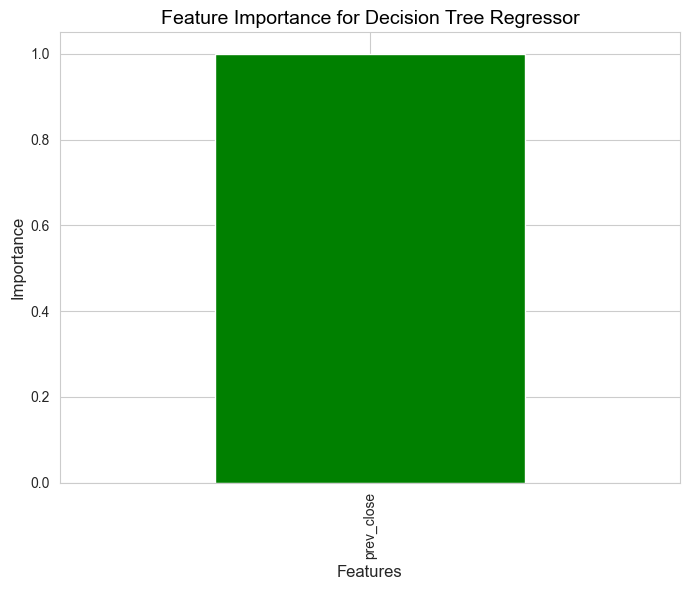

In [57]:
plt.figure(figsize=(7, 6))
feature_importance = pd.Series(decision_tree_model.feature_importances_, index=features)
feature_importance.plot(kind='bar', color='green')
plt.title('Feature Importance for Decision Tree Regressor', fontsize=14)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Importance', fontsize=12)
plt.tight_layout()
plt.show()

### Comparision of Models

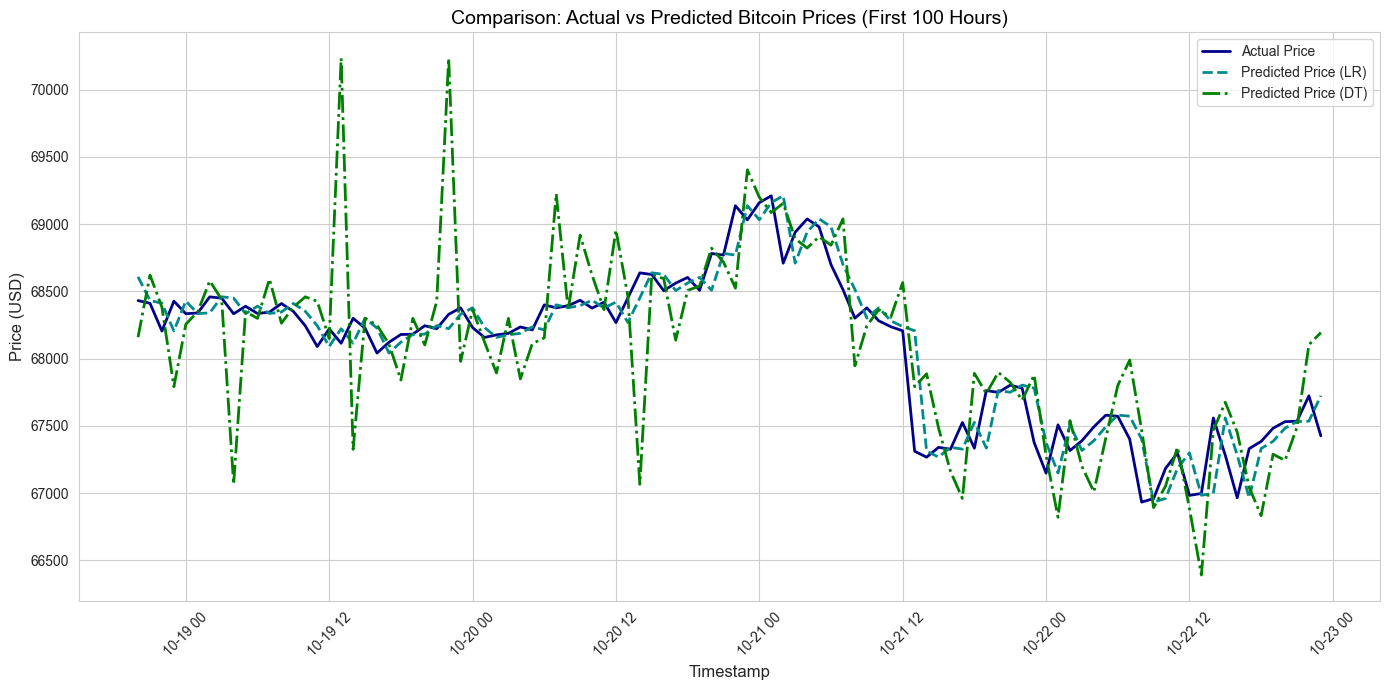

In [58]:
plt.figure(figsize=(14, 7))
plt.plot(y_test.index[:100], y_test[:100], label='Actual Price', color='darkblue', linewidth=2)
plt.plot(y_test.index[:100], y_pred_lr[:100], label='Predicted Price (LR)', color='darkcyan', linestyle='--', linewidth=2)
plt.plot(y_test.index[:100], y_pred_dt[:100], label='Predicted Price (DT)', color='green', linestyle='-.', linewidth=2)
plt.title('Comparison: Actual vs Predicted Bitcoin Prices (First 100 Hours)', fontsize=14)
plt.xlabel('Timestamp', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Models Performance Evaluation

In [59]:
performance_metrics_table = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree Regressor'],
    'Mean Absolute Error': [mae_lr, mae_dt],
    'Mean Squared Error': [mse_lr, mse_dt],
    'R² Score': [r2_lr, r2_dt],
    'Root Mean Squared Error': [rmse_lr, rmse_dt]
})
print("\nPerformance Metrics Table:")
print(performance_metrics_table.to_string(index=False))


Performance Metrics Table:
                  Model  Mean Absolute Error  Mean Squared Error  R² Score  Root Mean Squared Error
      Linear Regression           349.664262        2.849295e+05  0.997421               533.787853
Decision Tree Regressor         18377.940516        4.264819e+08 -2.859582             20651.438254


### Confusion Matrix for both Models

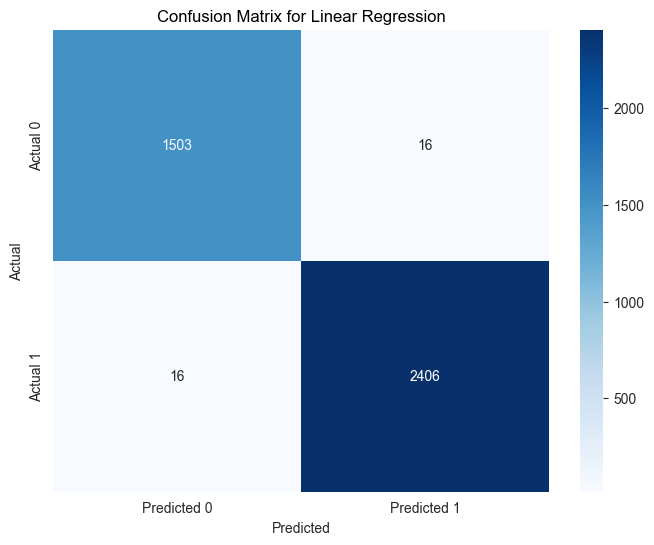

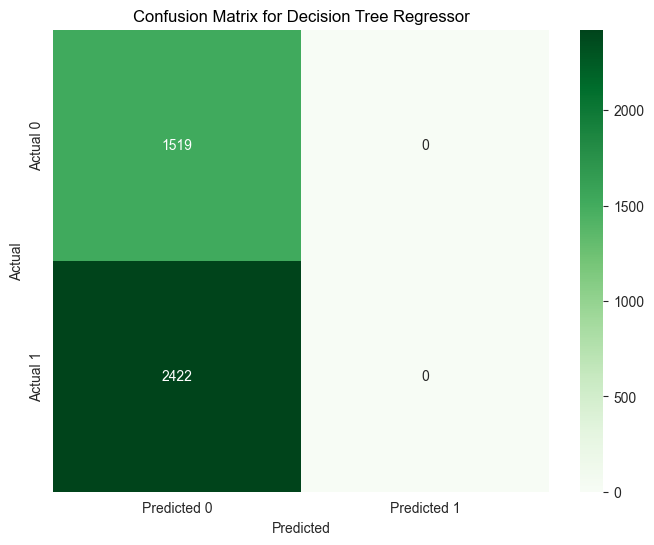

In [60]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_lr_class = (y_pred_lr > y_test.mean()).astype(int)
y_pred_dt_class = (y_pred_dt > y_test.mean()).astype(int)
y_test_class = (y_test > y_test.mean()).astype(int)

# Confusion Matrix for Linear Regression
cm_lr = confusion_matrix(y_test_class, y_pred_lr_class)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", 
            xticklabels=['Predicted 0', 'Predicted 1'], 
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Linear Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Confusion Matrix for Decision Tree Regressor
cm_dt = confusion_matrix(y_test_class, y_pred_dt_class)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Greens", 
            xticklabels=['Predicted 0', 'Predicted 1'], 
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Decision Tree Regressor')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
